# Question 1

## We first start with our import statements and data clean up

This file is independent of the others in this project because it requires significant computational resources to run. 

In [1]:
import kagglehub
# Download latest version
path = kagglehub.dataset_download("iamsouravbanerjee/cause-of-deaths-around-the-world")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\chees\.cache\kagglehub\datasets\iamsouravbanerjee\cause-of-deaths-around-the-world\versions\3


In [2]:
# Core packages
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

# Models
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVC

# Model selection and evaluation
from sklearn.model_selection import cross_val_score, GridSearchCV, LeaveOneOut, train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                            roc_auc_score, confusion_matrix, classification_report,
                            mean_squared_error, r2_score, mean_absolute_error)
# Preprocessing
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline 
from sklearn.model_selection import cross_val_predict  

filename="cause_of_deaths.csv"
df = pd.read_csv(path+"/"+filename) #import disease dataframe

df_hdi_raw = pd.read_csv("Human Development Index - Full.csv")

#df.head()

## Cleaning up chronic_df

In [3]:
# chronic causes

chronic_causes = ["Alzheimer's Disease and Other Dementias",
                  "Parkinson's Disease",'Cardiovascular Diseases',
                  'Neoplasms','Diabetes Mellitus','Chronic Kidney Disease',
                  'Chronic Respiratory Diseases','Cirrhosis and Other Chronic Liver Diseases', 'HIV/AIDS']


# Let me (Ivan) know if you think any of the other causes would fit under chronic causes
# Or if any currently under chronic causes should not be there

In [4]:
chronic_df = df[['Country/Territory','Code','Year'] + chronic_causes].copy()

chronic_df['Total Chronic Deaths'] = chronic_df[chronic_causes].sum(axis=1)

chronic_df.head(3)

,Country/Territory,Code,Year,Alzheimer's Disease and Other Dementias,Parkinson's Disease,Cardiovascular Diseases,Neoplasms,Diabetes Mellitus,Chronic Kidney Disease,Chronic Respiratory Diseases,Cirrhosis and Other Chronic Liver Diseases,HIV/AIDS,Total Chronic Deaths
0,Afghanistan,AFG,1990,1116,371,44899,11580,2108,3709,5945,2673,34,72435
1,Afghanistan,AFG,1991,1136,374,45492,11796,2120,3724,6050,2728,41,73461
2,Afghanistan,AFG,1992,1162,378,46557,12218,2153,3776,6223,2830,48,75345


In [5]:
# normalize the dataframe

normDf = pd.concat([chronic_df[chronic_causes].div(chronic_df[chronic_causes].sum(axis = 1), axis = 0), chronic_df[['Country/Territory', 'Code', 'Year', 'Total Chronic Deaths']]], axis=1)[['Country/Territory', 'Code', 'Year'] + chronic_causes + ['Total Chronic Deaths']]
normDf.head(2)

,Country/Territory,Code,Year,Alzheimer's Disease and Other Dementias,Parkinson's Disease,Cardiovascular Diseases,Neoplasms,Diabetes Mellitus,Chronic Kidney Disease,Chronic Respiratory Diseases,Cirrhosis and Other Chronic Liver Diseases,HIV/AIDS,Total Chronic Deaths
0,Afghanistan,AFG,1990,0.015407,0.005122,0.619852,0.159867,0.029102,0.051205,0.082074,0.036902,0.000469,72435
1,Afghanistan,AFG,1991,0.015464,0.005091,0.619267,0.160575,0.028859,0.050694,0.082357,0.037135,0.000558,73461


In [6]:
normDf_mean = normDf.groupby(['Country/Territory', 'Code'])[chronic_causes + ['Total Chronic Deaths']].mean() #mean of normDf
normDf_mean.head(3)

,,Alzheimer's Disease and Other Dementias,Parkinson's Disease,Cardiovascular Diseases,Neoplasms,Diabetes Mellitus,Chronic Kidney Disease,Chronic Respiratory Diseases,Cirrhosis and Other Chronic Liver Diseases,HIV/AIDS,Total Chronic Deaths
Country/Territory,Code,,,,,,,,,,
Afghanistan,AFG,0.015665,0.005004,0.602641,0.174575,0.034372,0.050301,0.079014,0.036889,0.001539,89082.966667
Albania,ALB,0.037107,0.010014,0.615455,0.234914,0.009396,0.017761,0.054609,0.020611,0.000134,14577.233333
Algeria,DZA,0.026061,0.006966,0.664508,0.144614,0.026801,0.047496,0.052858,0.028899,0.001797,107104.600000


## Cleaning up df_hdi_raw

In [7]:
pd.set_option('display.max_columns', None)

selected_columns = [
    col for col in df_hdi_raw.columns
    if any(
        phrase.lower() in col.lower()
        for phrase in [
            "Gross National Income",
            "Life Expectancy",
            "Human Development Index",
            "ISO3",
            "Country",
            "Human Development Groups"
        ]
    )
] #choosing our parameters (HDI, Life exp, human dev) 

df_selected_raw = df_hdi_raw[selected_columns]
df_hdi = df_selected_raw.drop(columns=[col for col in df_selected_raw.columns if 'male' in col.lower() or 'inequality' in col.lower() or 'Planetary pressures-adjusted' in col])

In [8]:
#melting
hdi_long = df_hdi.melt(
    id_vars=['Country'],
    var_name='Metric_Year',
    value_name='Value'
)

hdi_long['Metric'] = hdi_long['Metric_Year'].str.extract(r'^(.*) \(')
year_extracted = hdi_long['Metric_Year'].str.extract(r'\((\d{4})\)')
hdi_long['Year'] = pd.to_numeric(year_extracted[0], errors='coerce').astype('Int64')  

hdi_pivot = hdi_long.pivot_table(
    index=['Country', 'Year'],
    columns='Metric',
    values='Value'
).reset_index()

hdi_pivot.columns.name = None
hdi_pivot = hdi_pivot.rename(columns={
    'Human Development Index': 'HDI',
    'Life Expectancy at Birth': 'LifeExpectancy',
    'Gross National Income Per Capita': 'GNI_per_capita'
})

merged_df = pd.merge(
    chronic_df,
    hdi_pivot,
    how='inner',
    left_on=['Country/Territory', 'Year'],
    right_on=['Country', 'Year']
)

merged_df = merged_df.drop(columns=['Country'])
merged_df #our fully cleaned dataframe



,Country/Territory,Code,Year,Alzheimer's Disease and Other Dementias,Parkinson's Disease,Cardiovascular Diseases,Neoplasms,Diabetes Mellitus,Chronic Kidney Disease,Chronic Respiratory Diseases,Cirrhosis and Other Chronic Liver Diseases,HIV/AIDS,Total Chronic Deaths,GNI_per_capita,HDI,LifeExpectancy
0,Afghanistan,AFG,1990,1116,371,44899,11580,2108,3709,5945,2673,34,72435,2684.550019,0.273,45.9672
1,Afghanistan,AFG,1991,1136,374,45492,11796,2120,3724,6050,2728,41,73461,2276.289409,0.279,46.6631
2,Afghanistan,AFG,1992,1162,378,46557,12218,2153,3776,6223,2830,48,75345,2059.868084,0.287,47.5955
3,Afghanistan,AFG,1993,1187,384,47951,12634,2195,3862,6445,2943,56,77657,1525.533426,0.297,51.4664
4,Afghanistan,AFG,1994,1211,391,49308,12914,2231,3932,6664,3027,63,79741,1087.96189,0.292,51.4945
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5515,Zimbabwe,ZWE,2015,754,215,16649,11161,3176,2108,2751,1956,29162,67932,3638.532892,0.582,59.5911
5516,Zimbabwe,ZWE,2016,767,219,16937,11465,3259,2160,2788,1962,27141,66698,3606.750671,0.588,60.3059
5517,Zimbabwe,ZWE,2017,781,223,17187,11744,3313,2196,2818,2007,24846,65115,3728.918785,0.594,60.7095
5518,Zimbabwe,ZWE,2018,795,227,17460,12038,3381,2240,2849,2030,22106,63126,3864.012419,0.602,61.4141


## The DataFrame `merge.df` has the information from all countries through all years with all chronic diseases and the metrics HDI, LifeExp, GNI.


# Question 1

#### Does the death ratio (defined below) correlate with established development metrics such as HDI, GNI per capita, and life expectancy?
The death ratio is a 9-dimensional vector representing the conditional probability of dying from a specific chronic disease given that an individual has contracted any chronic disease: P(death from disease i | contracted a chronic disease), for 9 major chronic diseases.

### Method
We will answer this question by creating regressor models using the death ratio to predict `GNI_per_capita`, `HDI`, and `LifeExpectancy` (_**we need to define these**_).

We will first start with a K Nearest Neighbors Regressor. 

Text(0.5, 1.0, 'Countries with Missing Data')

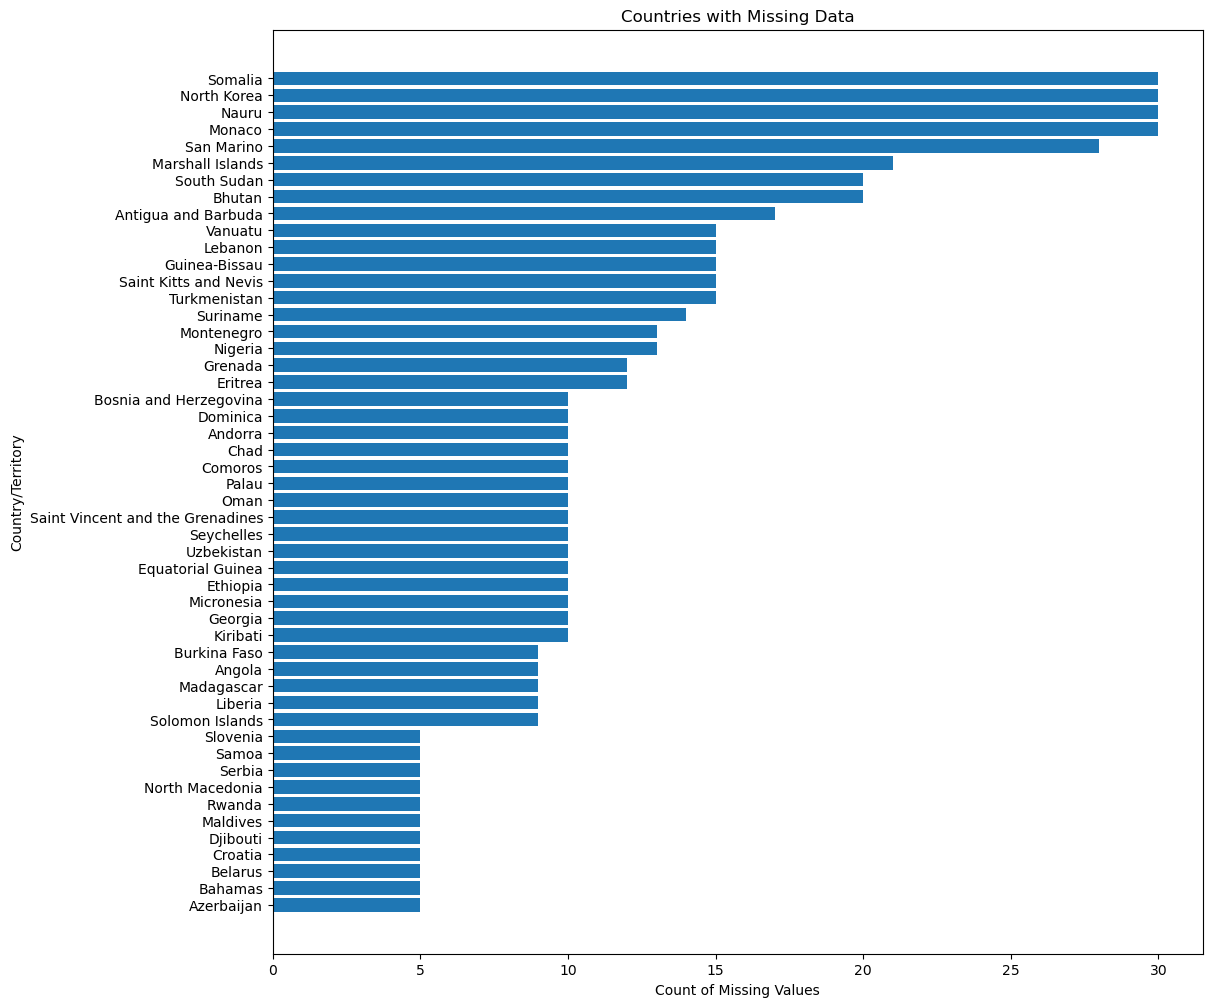

In [9]:
#before we get any further, we have some nans in our data. We will therefore drop those values. 615 rows are removed. A list of country with missing 
fig1 = plt.figure(figsize = (12,12))

# Get countries with missing values and their counts
missing_data = merged_df[merged_df.isna().any(axis=1)].groupby('Country/Territory').size().sort_values()

# Plot horizontal bar chart with both y-coordinates (countries) and x-coordinates (counts)
plt.barh(y=missing_data.index, width=missing_data.values)

plt.xlabel('Count of Missing Values')
plt.ylabel('Country/Territory')
plt.title('Countries with Missing Data')

## Remarks on Missing Data

Unfortunately, certain countries simply have some missing data for some values. This is usually because the country is ruled by a dicatator that wishes to control the narrative about their country (e.g. North Korea), is simply too remote/small to have all the data collected (e.g. Andorra, Bhutan), or is in a war (e.g. South Sudan). 

For the purposes of investigating the death ratio as a metric, we will disregard all country-year combos with even a single missing value. We can do this because the specific country that some death ratio belongs to is independent of the actaul metrics. Removing this data will not be detremental to our results. 

Also, notice that there is no visual correlation between the number of missing rows and the metrics for each country. 

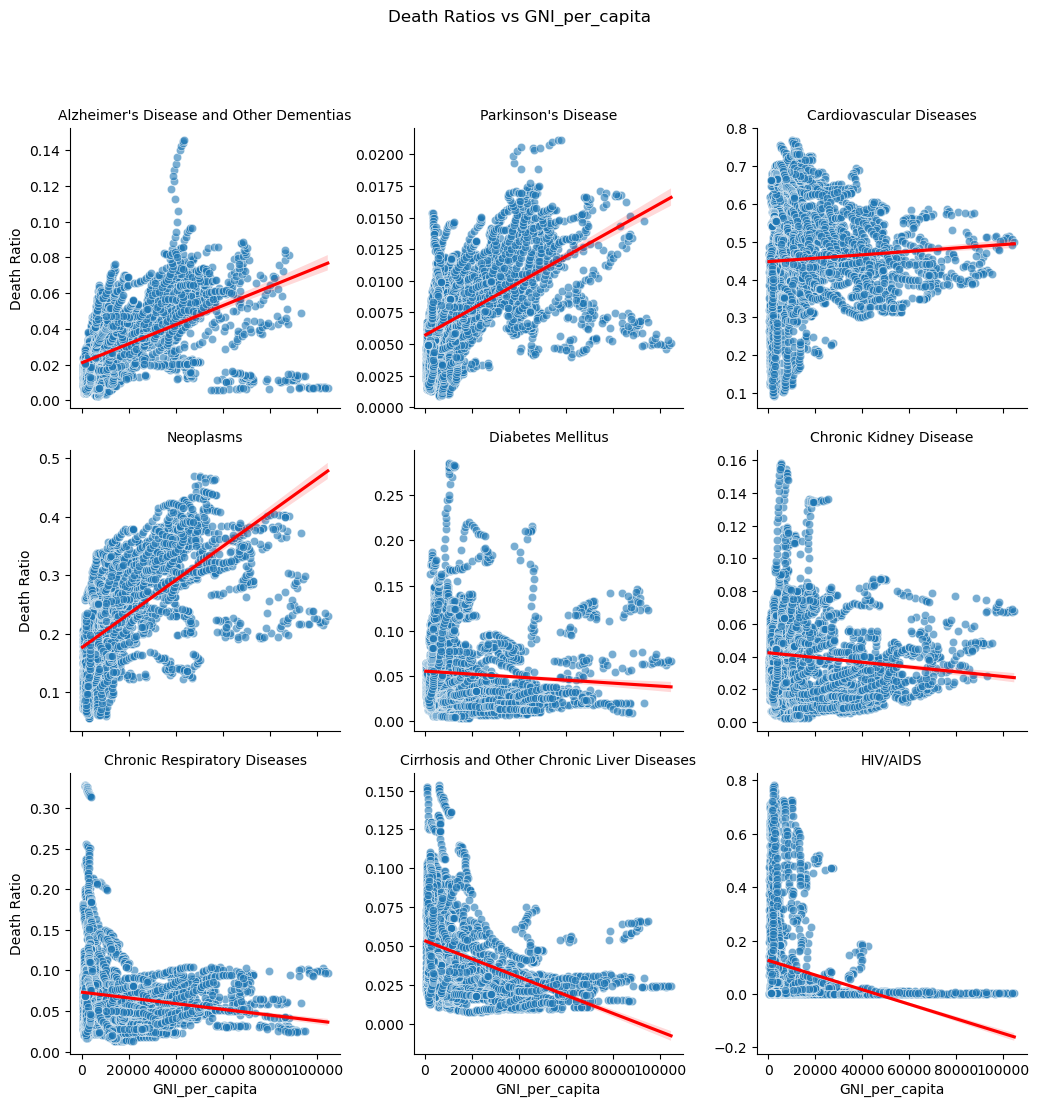

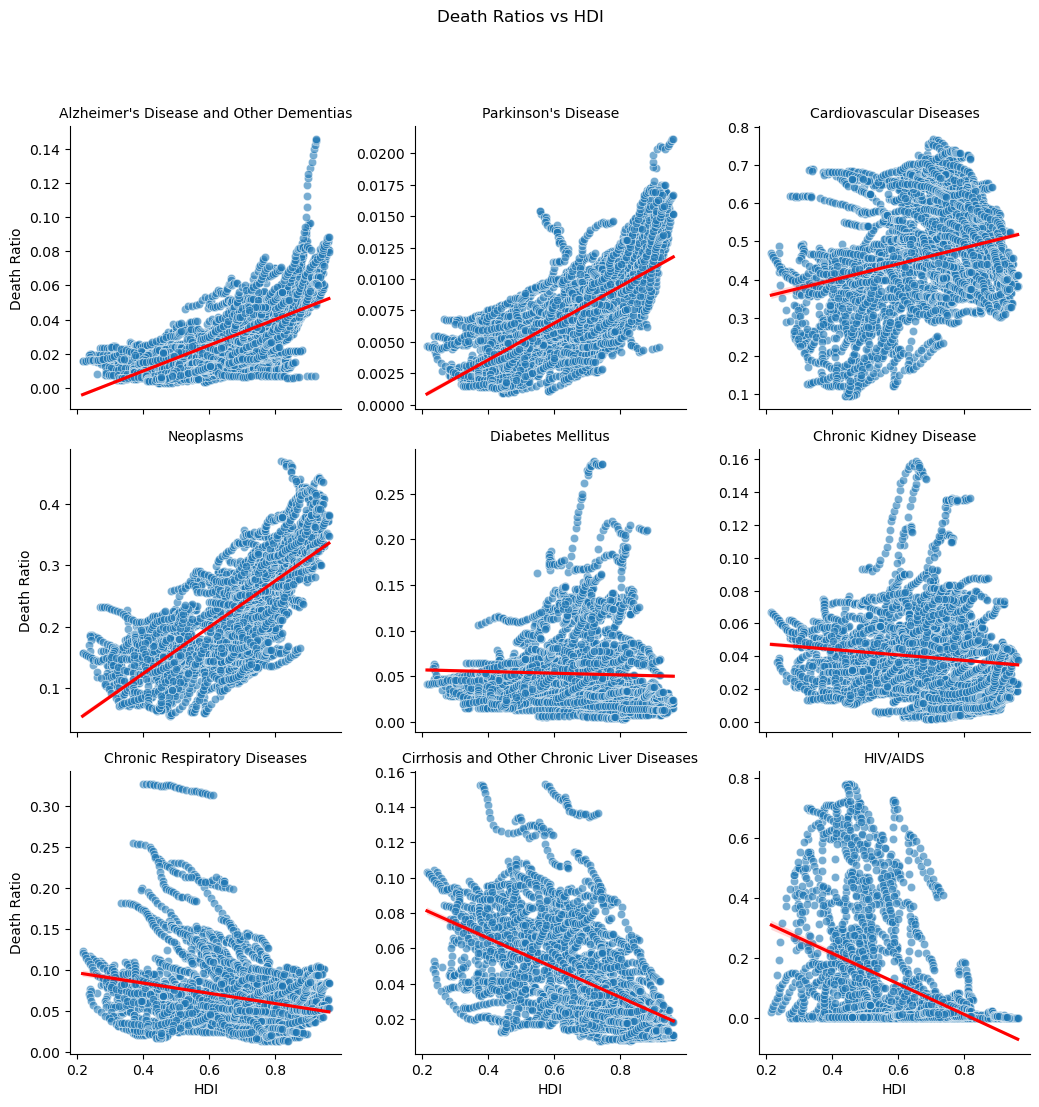

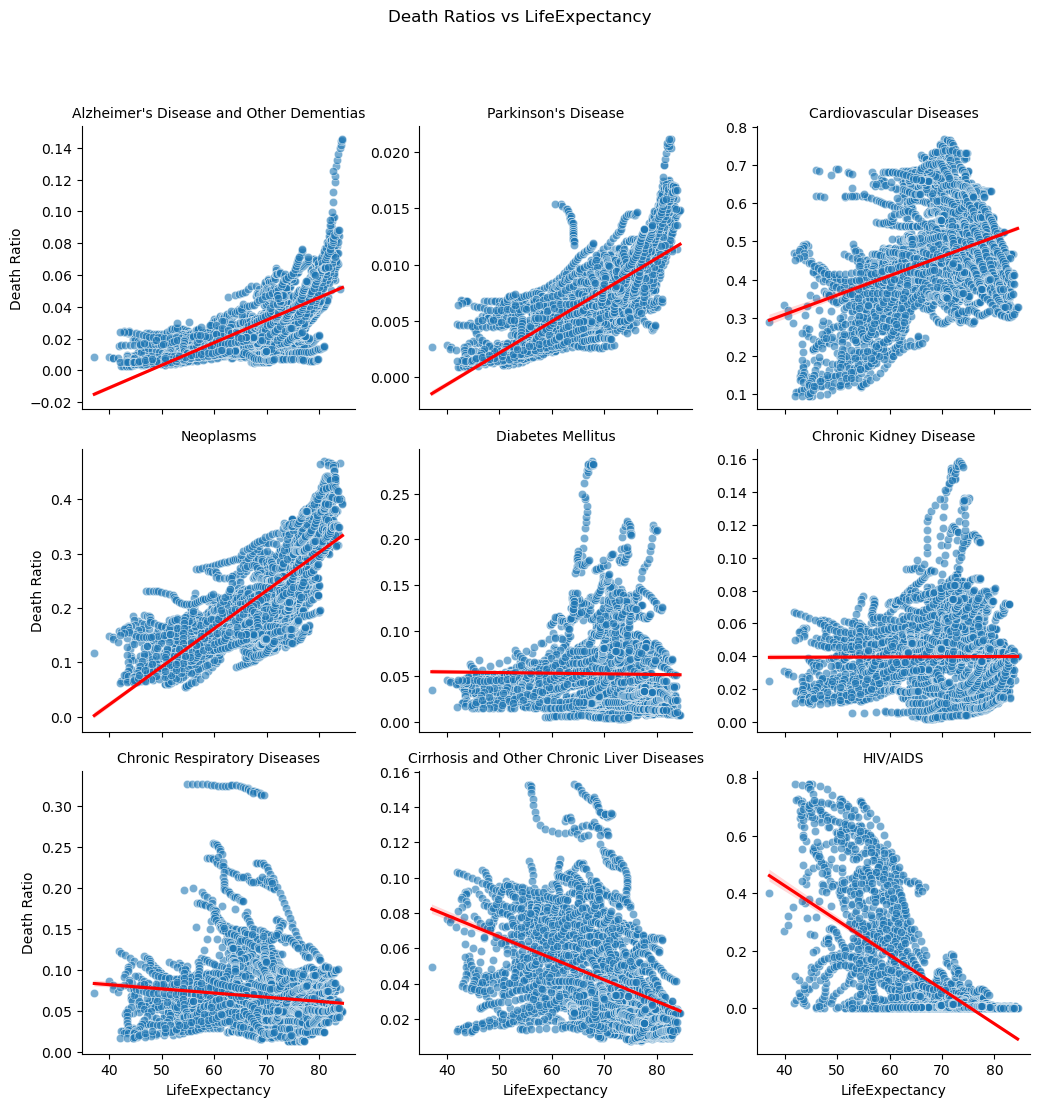

In [10]:

death_ratio = merged_df[chronic_causes].apply(pd.to_numeric, errors='coerce').divide(
    merged_df['Total Chronic Deaths'], axis=0)

plot_df = pd.concat([
    merged_df[['GNI_per_capita', 'HDI', 'LifeExpectancy']].apply(pd.to_numeric, errors='coerce'),  # Convert metrics to numeric
    death_ratio
], axis=1)

plot_df = plot_df.dropna()

# Melt for seaborn
melted = plot_df.melt(
    id_vars=['GNI_per_capita', 'HDI', 'LifeExpectancy'],
    value_vars=chronic_causes,
    var_name='Cause',
    value_name='Death Ratio'
)
#graohing 
metrics = ['GNI_per_capita', 'HDI', 'LifeExpectancy']
for metric in metrics:
    g = sns.FacetGrid(
        melted, col='Cause', col_wrap=3, height=3.5, sharey=False
    )
    g.map_dataframe(
        sns.scatterplot, x=metric, y='Death Ratio', alpha=0.6
    )
    g.map_dataframe(
        sns.regplot, x=metric, y='Death Ratio', scatter=False, color='red'
    )
    g.set_titles("{col_name}")
    g.fig.suptitle(f"Death Ratios vs {metric}", y=1.05)
    plt.tight_layout()
    plt.show()

## Remarks: EDA

This is just for a quick visual of correlation between the individual death ratio component and the metrics. We make more remarks upon the data in the written report. For now, we will point out the it seems only a few diseases have strong monotonic correlation with any given metric.

In [11]:
#set up all the vectors to be put into the predictors
death_ratio = merged_df[chronic_causes].divide(merged_df['Total Chronic Deaths'], axis = 0) # P(death from disease i | contracted a chronic disease)
y_gni = merged_df['GNI_per_capita'] #a column with all the GNI's for each country-year pair
y_life = merged_df['LifeExpectancy'] #for life expectancy
y_hdi = merged_df['HDI'] #for HDI

In [12]:
targets = {
    'GNI_per_capita': y_gni,
    'LifeExpectancy': y_life,
    'HDI': y_hdi
}


param_grid = {
    'scaler__with_mean': [True, False],
    'scaler__with_std': [True, False],
    'knn__n_neighbors': range(1, 500, 5),
    'knn__metric': ['euclidean', 'manhattan', 'minkowski']
}

In [13]:
# Define X (death ratio)
X = merged_df[chronic_causes].divide(merged_df['Total Chronic Deaths'], axis=0)
results = []

# Loop over targets
for name, y in targets.items():
    # Combine X and y into a single DataFrame and drop rows with NaNs
    data = pd.concat([X, y], axis=1).dropna()
    
    X_clean = data[chronic_causes]
    y_clean = data[name]
    
    # Define pipeline
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsRegressor())
    ])

    # Grid search
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=5,
        scoring='neg_mean_squared_error',
        n_jobs=-1
    )

    grid_search.fit(X_clean, y_clean)

    # Evaluate
    y_pred = grid_search.predict(X_clean)
    mse = mean_squared_error(y_clean, y_pred)
    r2 = r2_score(y_clean, y_pred)

    results.append({
        'Target': name,
        'Best Params': grid_search.best_params_,
        'Best n_neighbors': grid_search.best_params_['knn__n_neighbors'],
        'Best metric': grid_search.best_params_['knn__metric'],
        'with_mean': grid_search.best_params_['scaler__with_mean'],
        'with_std': grid_search.best_params_['scaler__with_std'],
        'MSE': mse,
        'R²': r2
    })

In [14]:
pd.DataFrame(results).sort_values(by='R²').drop(columns = ['Best Params'])

,Target,Best n_neighbors,Best metric,with_mean,with_std,MSE,R²
0,GNI_per_capita,311,euclidean,True,True,1.434944e+08,0.579745
1,LifeExpectancy,86,manhattan,True,True,1.314631e+01,0.860633
2,HDI,81,manhattan,True,True,3.395444e-03,0.875274


## Remarks on using an all feature KNN model.

We can see that our predictor functions reasonably well when predicting life expectancy and HDI with the r2 score being abouve 86% for both. Interpreting, this indicates that ~86% of the variation of HDI and life expectancy can be attributed to differences in the death ratio. Unexpectedly, the model predicted GNI per capita very poorly. 

To discuss the GNI per capita accraucy further, we first note that HDI is a function of both life expectancy, GNI per capita, and some other metrics. As both life expectancy and HDI correlated reasonably well with the death ratio, the intuitive expectation for GNI per capita is also a reasonable correlation, but this is clearly not the case.

Looking at the precise definition of HDI, we see that it is simply the geometric mean of the standardize life expectancy, GNI per capita, and mean years of schooling, so there is really no reason for GNI per capita to predict so poorly.

## Next Steps: Feature optimization

We are left with the thought that perhaps certain chronic diseases share no correlation with our metrics to predict. Thus, we shall do some feature optimization. We will test using 2, 3, and 4 diseases to check which diseases are really the best predictors.

In doing this, we will recompute the death ratio with 2, 3, and 4 elements in the vector for continuity. Ideally, we would test with all number of diseases (1-8) but that is very computationally demanding so we limit our query. 

In [15]:
from sklearn.impute import SimpleImputer

results = []

for target_name, y in targets.items():
    for k in [2, 3, 4]:
        for combo in combinations(chronic_causes, k):
            # Subset DataFrame to only selected chronic diseases
            subset_df = merged_df[list(combo) + ['Total Chronic Deaths', target_name]].dropna()
            
            X = subset_df[list(combo)].div(subset_df[list(combo)].sum(axis=1), axis=0)
            y_clean = subset_df[target_name]
            
            if X.isna().any().any():
                pipeline = Pipeline([
                    ('imputer', SimpleImputer(strategy='mean')),  # Replace NaN with mean values
                    ('scaler', StandardScaler()),
                    ('knn', KNeighborsRegressor())
                ])
                
                param_grid = {
                    'scaler__with_mean': [True, False],
                    'scaler__with_std': [True, False],
                    'knn__n_neighbors': range(1, 100, 5),
                    'knn__metric': ['euclidean', 'manhattan', 'minkowski']
                }
            else:
                pipeline = Pipeline([
                    ('scaler', StandardScaler()),
                    ('knn', KNeighborsRegressor())
                ])
            
            # Grid search
            grid_search = GridSearchCV(
                estimator=pipeline,
                param_grid=param_grid,
                cv=5,
                scoring='neg_mean_squared_error',
                n_jobs=-1
            )
            
            grid_search.fit(X, y_clean)
            
            # Evaluate
            y_pred = grid_search.predict(X)
            mse = mean_squared_error(y_clean, y_pred)
            r2 = r2_score(y_clean, y_pred)
            
            results.append({
                'Target': target_name,
                'Num Features': k,
                'Features': combo,
                'Best Params': grid_search.best_params_,
                'MSE': mse,
                'R²': r2
            })

# Create results DataFrame
feature_opt_results = pd.DataFrame(results)

feature_opt_results = feature_opt_results.sort_values(by=['Target', 'R²'], ascending=[True, False])

feature_opt_results

,Target,Num Features,Features,Best Params,MSE,R²
141,GNI_per_capita,4,"(Alzheimer's Disease and Other Dementias, Card...","{'knn__metric': 'euclidean', 'knn__n_neighbors...",1.037571e+08,0.696124
129,GNI_per_capita,4,"(Alzheimer's Disease and Other Dementias, Park...","{'knn__metric': 'euclidean', 'knn__n_neighbors...",1.101410e+08,0.677427
145,GNI_per_capita,4,"(Alzheimer's Disease and Other Dementias, Card...","{'knn__metric': 'manhattan', 'knn__n_neighbors...",1.244673e+08,0.635470
120,GNI_per_capita,4,"(Alzheimer's Disease and Other Dementias, Park...","{'knn__metric': 'euclidean', 'knn__n_neighbors...",1.272423e+08,0.627343
191,GNI_per_capita,4,"(Parkinson's Disease, Neoplasms, Diabetes Mell...","{'knn__metric': 'manhattan', 'knn__n_neighbors...",1.288747e+08,0.622562
...,...,...,...,...,...,...
255,LifeExpectancy,2,"(Parkinson's Disease, Neoplasms)","{'knn__metric': 'euclidean', 'knn__n_neighbors...",7.836945e+01,0.169187
274,LifeExpectancy,2,"(Diabetes Mellitus, Cirrhosis and Other Chroni...","{'knn__metric': 'euclidean', 'knn__n_neighbors...",7.929454e+01,0.159380
273,LifeExpectancy,2,"(Diabetes Mellitus, Chronic Respiratory Diseases)","{'knn__metric': 'euclidean', 'knn__n_neighbors...",8.082096e+01,0.143198
276,LifeExpectancy,2,"(Chronic Kidney Disease, Chronic Respiratory D...","{'knn__metric': 'euclidean', 'knn__n_neighbors...",8.247269e+01,0.125687


In [16]:
best_per_target = feature_opt_results.loc[
    feature_opt_results.groupby('Target')['R²'].idxmax()
].reset_index(drop=True)
best_per_target

,Target,Num Features,Features,Best Params,MSE,R²
0,GNI_per_capita,4,"(Alzheimer's Disease and Other Dementias, Card...","{'knn__metric': 'euclidean', 'knn__n_neighbors...",1.037571e+08,0.696124
1,HDI,4,"(Cardiovascular Diseases, Neoplasms, Chronic R...","{'knn__metric': 'manhattan', 'knn__n_neighbors...",5.196774e-03,0.809106
2,LifeExpectancy,4,"(Alzheimer's Disease and Other Dementias, Card...","{'knn__metric': 'manhattan', 'knn__n_neighbors...",1.708488e+01,0.818879


## Remarks on feature optimization

Overall, feature optimization with only 4 features was a bad idea. We see that the best models have maxed out number of features. In our next test, we will go through to 9 features to check if there is an optimal number of features. 

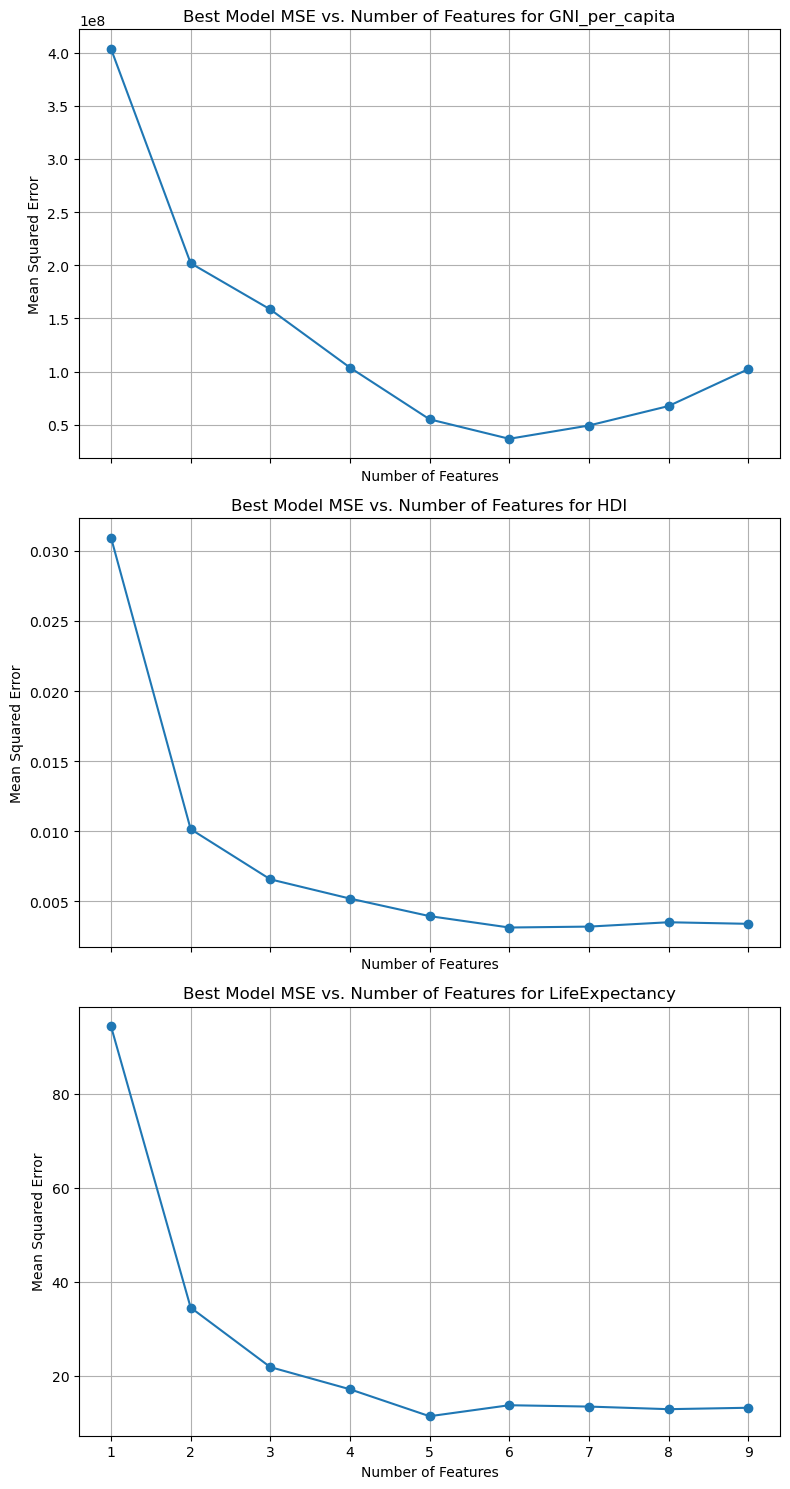

In [17]:
# One is strongly adivsed AGAINST running this code without at least a desktop machine.
# This code was run on an AMD 9800x3d and still took in excess of thirty minutes to run.
results = []

for target_name, y in targets.items():
    for k in range(1, 10):  # Now going 1 through 9 features
        for combo in combinations(chronic_causes, k):
            # Subset the DataFrame to only selected chronic diseases
            subset_df = merged_df[list(combo) + ['Total Chronic Deaths', target_name]].dropna()
            
            # Normalize so features sum to 1
            X = subset_df[list(combo)].div(subset_df[list(combo)].sum(axis=1), axis=0)
            y_clean = subset_df[target_name]
            
            if X.isna().any().any():
                pipeline = Pipeline([
                    ('imputer', SimpleImputer(strategy='mean')),
                    ('scaler', StandardScaler()),
                    ('knn', KNeighborsRegressor())
                ])
            else:
                pipeline = Pipeline([
                    ('scaler', StandardScaler()),
                    ('knn', KNeighborsRegressor())
                ])
            
            param_grid = {
                'scaler__with_mean': [True, False],
                'scaler__with_std': [True, False],
                'knn__n_neighbors': range(1, 100, 5),
                'knn__metric': ['euclidean', 'manhattan', 'minkowski']
            }
            
            grid_search = GridSearchCV(
                estimator=pipeline,
                param_grid=param_grid,
                cv=5,
                scoring='neg_mean_squared_error',
                n_jobs=-1
            )
            grid_search.fit(X, y_clean)
            
            y_pred = grid_search.predict(X)
            mse = mean_squared_error(y_clean, y_pred)
            r2 = r2_score(y_clean, y_pred)
            
            results.append({
                'Target': target_name,
                'Num Features': k,
                'Features': combo,
                'Best Params': grid_search.best_params_,
                'MSE': mse,
                'R²': r2
            })

feature_opt_results = pd.DataFrame(results)

best_per_k = (
    feature_opt_results
    .sort_values(by=['Target', 'Num Features', 'R²'], ascending=[True, True, False])
    .groupby(['Target', 'Num Features'], as_index=False)
    .first()
)

targets = best_per_k['Target'].unique()
fig, axes = plt.subplots(len(targets), 1, figsize=(8, 5 * len(targets)), sharex=True)

if len(targets) == 1:
    axes = [axes]  

for ax, target in zip(axes, targets):
    subset = best_per_k[best_per_k['Target'] == target]
    ax.plot(subset['Num Features'], subset['MSE'], marker='o', linestyle='-')
    ax.set_title(f"Best Model MSE vs. Number of Features for {target}")
    ax.set_xlabel("Number of Features")
    ax.set_ylabel("Mean Squared Error")
    ax.grid(True)

plt.tight_layout()
plt.show()

## Remark feature search

See the written report.

In [18]:
best_models = feature_opt_results.loc[
    feature_opt_results.groupby('Target')['R²'].idxmax()
].reset_index(drop=True)

pd.set_option('display.max_rows', None) 
pd.set_option('display.max_columns', None)  
pd.set_option('display.max_colwidth', None)  
pd.set_option('display.width', None) 

best_models

,Target,Num Features,Features,Best Params,MSE,R²
0,GNI_per_capita,6,"(Alzheimer's Disease and Other Dementias, Parkinson's Disease, Cardiovascular Diseases, Neoplasms, Diabetes Mellitus, Chronic Kidney Disease)","{'knn__metric': 'euclidean', 'knn__n_neighbors': 21, 'scaler__with_mean': True, 'scaler__with_std': True}",3.677352e+07,0.892301
1,HDI,6,"(Parkinson's Disease, Cardiovascular Diseases, Diabetes Mellitus, Chronic Kidney Disease, Chronic Respiratory Diseases, Cirrhosis and Other Chronic Liver Diseases)","{'knn__metric': 'euclidean', 'knn__n_neighbors': 46, 'scaler__with_mean': True, 'scaler__with_std': True}",3.132802e-03,0.884922
2,LifeExpectancy,5,"(Parkinson's Disease, Cardiovascular Diseases, Diabetes Mellitus, Chronic Kidney Disease, HIV/AIDS)","{'knn__metric': 'euclidean', 'knn__n_neighbors': 21, 'scaler__with_mean': True, 'scaler__with_std': True}",1.134481e+01,0.879731


# Remark:

We shall conduct our final analysis on the written report. 